In [1]:
from github_helper import from_github
import pandas as pd
from tqdm import tqdm
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
edge_df = pd.read_csv(from_github("/edges/party/all_party_edges_by_Period.csv"))

# edge_df = edge_df[edge_df['Period']!=65]
#We drop Period 65, as it does not seem to be representative. It should be done in "enriched_votes_calculations"
edge_df.head()



,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Dansk Folkeparti,Dansk Folkeparti,65,21507,21480.0,0.998745,finans_budget
1,Dansk Folkeparti,Det Konservative Folkeparti,65,21913,21619.0,0.986583,finans_budget
2,Dansk Folkeparti,Enhedslisten,65,3115,846.0,0.271589,finans_budget
3,Dansk Folkeparti,Inuit Ataqatigiit,65,164,15.0,0.091463,finans_budget
4,Dansk Folkeparti,Kristendemokraterne,65,6146,2830.0,0.460462,finans_budget


In [3]:
edge_df['target'].unique()

array(['Dansk Folkeparti', 'Det Konservative Folkeparti', 'Enhedslisten',
       'Inuit Ataqatigiit', 'Kristendemokraterne', 'Radikale Venstre',
       'Socialdemokratiet', 'Socialistisk Folkeparti', 'Tjóðveldi',
       'Venstre', 'Fólkaflokkurin', 'Siumut',
       'Uden for Folketingsgrupperne', 'Liberal Alliance',
       'Sambandsflokkurin', 'Alternativet', 'Nye Borgerlige',
       'Danmarksdemokraterne', 'Moderaterne', 'Javnaðarflokkurin'],
      dtype=object)

In [13]:
traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
# #KAN VI FINDE NOGET MED NY ALLIANCE?????? HVOR ER DE????
mask_only_traditional_parties = (edge_df['source'].isin(traditional_parties)) & (edge_df['target'].isin(traditional_parties))
edge_traditional = edge_df[mask_only_traditional_parties]
# edge_traditional = edge_df

In [14]:
# #We drop all observations, where the parties share less than 20 votes in a year, as this is not representative of the party.
# #Example: In period 66, LA has agreement with a lot of parties on a lot of topics, because they share very few votes.
# # edge_limited = edge_traditional[edge_traditional['total_votes_shared']>25] #OR WE COULD DROP LA IN PERIOD 66?
# # Let's do a scatterplot, just for LA in period 66 to justify
# # edge_limited = edge_traditional
# mask_la_in_66 = ((edge_traditional['source'] == "Liberal Alliance") | (edge_traditional['target'] == "Liberal Alliance")) & (edge_traditional['Period']==66) #Use this mask to show
# edges_only_la = edge_traditional[mask_la_in_66]
# la_la_mask = (edges_only_la['source'] == "Liberal Alliance") & (edges_only_la['target'] == "Liberal Alliance")
# # edges_only_la[~la_la_mask].groupby("topic").sum()
# # .groupby("topic")
# edges_only_la

In [16]:

# edge_limited = edge_traditional[~mask_la_in_66] 
edge_limited = edge_traditional

In [17]:
periods = [66, 67, 68, 69, 70, 71] # 65
wide = (
    edge_limited
    .pivot_table(
        index=['source', 'target', 'topic'],  # one row per pair+topic
        columns='Period',                     # one column per period
        values='weight',                      # values to fill
        aggfunc='first'                       # or 'mean' if you can have duplicates
    )
    .reindex(columns=periods)                 # ensure column order 65..71
)

# make Period columns normal columns instead of a MultiIndex
wide = wide.reset_index()
wide

Period,source,target,topic,66,67,68,69,70,71
0,Dansk Folkeparti,Dansk Folkeparti,arbejdsmarked_velfærd,0.998244,0.985038,0.995356,0.999495,0.977993,0.989305
1,Dansk Folkeparti,Dansk Folkeparti,bolig,0.999254,0.984513,0.998049,0.999627,0.962711,1.000000
2,Dansk Folkeparti,Dansk Folkeparti,erhverv,0.998065,0.987415,0.996816,0.999872,0.969340,0.987076
3,Dansk Folkeparti,Dansk Folkeparti,finans_budget,0.998952,0.990742,0.998513,0.999430,0.987129,0.983811
4,Dansk Folkeparti,Dansk Folkeparti,forsvar_sikkerhed,0.997514,0.991283,1.000000,0.999308,0.991959,0.984906
...,...,...,...,...,...,...,...,...,...
535,Venstre,Venstre,social_familie,0.986137,0.998191,0.998982,0.999727,0.985727,0.991632
536,Venstre,Venstre,sundhed,0.983517,0.999598,0.998653,0.999792,0.989505,0.992727
537,Venstre,Venstre,transport_infrastruktur,0.999527,0.998558,0.999321,0.999537,0.990994,0.994431
538,Venstre,Venstre,uddannelse,0.982104,0.999747,0.998594,0.999505,0.990859,0.986916


In [18]:
diffs = []
for a, b in combinations(periods, 2):
    # Compute difference but set it to NaN if either side is NaN
    diff = (wide[a] - wide[b]).abs()
    
    # mask invalid diffs where one or both values were missing
    invalid_mask = wide[[a, b]].isna().any(axis=1)
    diff[invalid_mask] = np.nan
    
    diffs.append(diff)

# Combine while ignoring NaN values
wide["biggest_change"] = np.nanmax(np.column_stack(diffs), axis=1)
wide_sorted = wide.sort_values("biggest_change", ascending=False)
wide_sorted

Period,source,target,topic,66,67,68,69,70,71,biggest_change
111,Dansk Folkeparti,Venstre,immigration,0.904362,0.869726,0.633011,0.686584,0.606890,0.281978,0.622384
306,Enhedslisten,Venstre,immigration,0.200180,0.233423,0.400780,0.338009,0.452077,0.703677,0.503497
483,Socialdemokratiet,Venstre,finans_budget,0.578015,0.515794,0.635412,0.692905,0.653585,0.995905,0.480111
487,Socialdemokratiet,Venstre,klima_miljø,0.535073,0.593235,0.684935,0.820806,0.802141,0.995599,0.460526
491,Socialdemokratiet,Venstre,sundhed,0.579778,0.539194,0.746228,0.848366,0.757642,0.996502,0.457308
...,...,...,...,...,...,...,...,...,...,...
129,Det Konservative Folkeparti,Det Konservative Folkeparti,skat,1.000000,0.998041,0.997457,0.997999,0.993602,1.000000,0.006398
122,Det Konservative Folkeparti,Det Konservative Folkeparti,erhverv,1.000000,0.996173,1.000000,1.000000,0.993663,0.996185,0.006337
232,Enhedslisten,Enhedslisten,klima_miljø,0.996454,1.000000,1.000000,0.998056,0.995295,0.996897,0.004705
237,Enhedslisten,Enhedslisten,transport_infrastruktur,1.000000,1.000000,0.997532,0.998916,0.997191,0.996513,0.003487


<Axes: xlabel='biggest_change', ylabel='Count'>

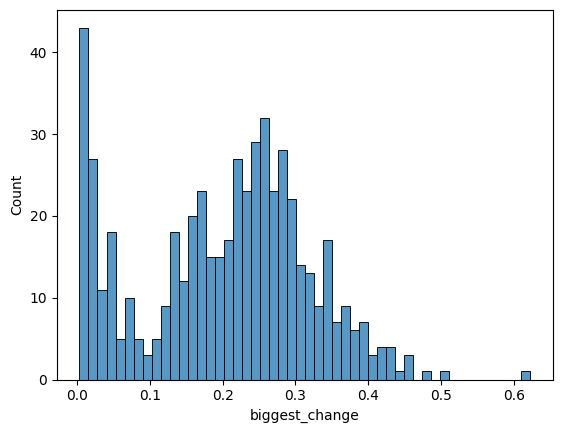

In [19]:
sns.histplot(
    data = wide_sorted
    ,x = "biggest_change"
    ,bins = 50
)

In [20]:
wide_sorted["diff_66_71"] = (wide_sorted[71] - wide_sorted[66]).abs()
wide_sorted

Period,source,target,topic,66,67,68,69,70,71,biggest_change,diff_66_71
111,Dansk Folkeparti,Venstre,immigration,0.904362,0.869726,0.633011,0.686584,0.606890,0.281978,0.622384,0.622384
306,Enhedslisten,Venstre,immigration,0.200180,0.233423,0.400780,0.338009,0.452077,0.703677,0.503497,0.503497
483,Socialdemokratiet,Venstre,finans_budget,0.578015,0.515794,0.635412,0.692905,0.653585,0.995905,0.480111,0.417890
487,Socialdemokratiet,Venstre,klima_miljø,0.535073,0.593235,0.684935,0.820806,0.802141,0.995599,0.460526,0.460526
491,Socialdemokratiet,Venstre,sundhed,0.579778,0.539194,0.746228,0.848366,0.757642,0.996502,0.457308,0.416724
...,...,...,...,...,...,...,...,...,...,...,...
129,Det Konservative Folkeparti,Det Konservative Folkeparti,skat,1.000000,0.998041,0.997457,0.997999,0.993602,1.000000,0.006398,0.000000
122,Det Konservative Folkeparti,Det Konservative Folkeparti,erhverv,1.000000,0.996173,1.000000,1.000000,0.993663,0.996185,0.006337,0.003815
232,Enhedslisten,Enhedslisten,klima_miljø,0.996454,1.000000,1.000000,0.998056,0.995295,0.996897,0.004705,0.000443
237,Enhedslisten,Enhedslisten,transport_infrastruktur,1.000000,1.000000,0.997532,0.998916,0.997191,0.996513,0.003487,0.003487


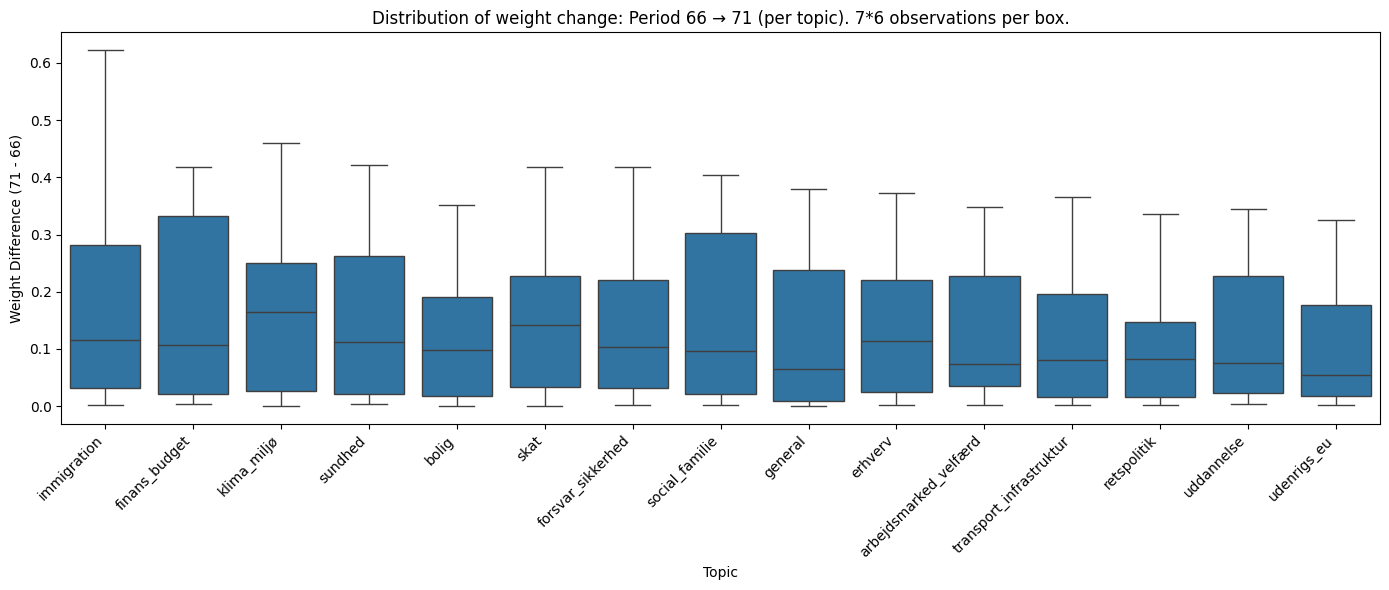

In [21]:

# medians = wide_sorted.groupby("topic")["diff_66_71"].mean().sort_values()
# wide_sorted["topic"] = pd.Categorical(
#     wide_sorted["topic"],
#     categories=medians.index,
#     ordered=True
# )


plt.figure(figsize=(14, 6))

sns.boxplot(
    data=wide_sorted,
    x="topic",
    y="diff_66_71",
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of weight change: Period 66 → 71 (per topic). 7*6 observations per box.")
plt.xlabel("Topic")
plt.ylabel("Weight Difference (71 - 66)")

plt.tight_layout()
plt.show()